<a href="https://colab.research.google.com/github/niranjan324/Micro-projects/blob/main/24BSE1211_PDE_MicroProject_Group12_Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1D Image Blurring and Restoration — Phase 2 (Micro-Project)
### Computational Simulation of the Heat-Equation Blurring Model

**Group 12 — Course 24BSE1211 — PDE Micro-Project**

This notebook implements the closed-form Fourier-series solution derived analytically
in Phase 1 and uses it to numerically simulate and visualise the diffusion (blurring)
of a sharp clinical edge along a 1D scan line, governed by

$$\frac{\partial I(x,t)}{\partial t} = \alpha\,\frac{\partial^2 I(x,t)}{\partial x^2}, \qquad 0<x<L,$$

with insulated (Neumann) boundary conditions $I_x(0,t)=I_x(L,t)=0$ and a step-function
initial condition representing a sharp edge between two tissue intensities $I_0$ and $I_1$.


## Algorithm

This project simulates the one-dimensional diffusion (blurring) of a sharp clinical edge using a Fourier-series solution to the heat equation. The core algorithm can be broken down into the following steps:

1.  **Initialization of Physical Parameters**: Essential physical and model parameters are defined, including `L` (length), `I0`, `I1` (initial intensities), `alpha` (diffusion coefficient), `x0` (edge location), and `N_TERMS` (number of Fourier harmonics).

2.  **Implementation of Fourier Series Solution**: The `I_xt(x, t, N)` function directly implements the analytical Fourier-series solution. It calculates the intensity `I` at a given position `x` and time `t` by:
    *   Summing a DC (mean) term.
    *   Iterating through `N` odd harmonics (n = 1, 3, 5, ..., 2N-1).
    *   Calculating each harmonic's coefficient `a_n` using `fourier_coefficient(n)`.
    *   Multiplying each harmonic by `cos(n * pi * x / L)` and an exponential decay factor `exp(-alpha * (n * pi / L)**2 * t)`, which models time-dependent diffusion.

3.  **Visualizing Diffusion**: The algorithm visualizes the blurring effect by calculating `I_xt` at different time steps (e.g., t = 0.0, 0.1, 0.5) and plotting these intensity profiles to show the progressive smoothing of the sharp edge.

4.  **Low-Pass Filtering Analysis**: To explain the blurring mechanism, the retained amplitude of each odd harmonic is plotted for different time steps. This demonstrates how higher-frequency components decay much faster, illustrating the low-pass filtering effect of diffusion in the frequency domain.

5.  **Convergence Check (Gibbs Phenomenon)**: A convergence check plots `I_xt` at `t=0` with varying numbers of Fourier terms (`N`). This shows the Gibbs phenomenon (overshoot near discontinuities) and verifies that a sufficiently high `N_TERMS` ensures visual convergence for practical purposes.

6.  **Image Restoration (Inverse Filtering - Conceptual)**: Based on the understanding that blurring is a low-pass filter, the project concludes by discussing **inverse filtering** as a restoration strategy. This conceptually involves computing Fourier series coefficients of a blurred image, applying an inverse transfer function to re-amplify attenuated high-frequency components, and reconstructing the image to recover the original sharp edge. The challenges of noise amplification in such an ill-posed problem are also noted.

## 1. Approach

From Phase 1, the exact series solution of the initial-boundary value problem is

$$I(x,t) = \frac{I_0+I_1}{2} + \frac{2(I_0-I_1)}{\pi}\sum_{k=1}^{\infty}
\frac{(-1)^{k+1}}{2k-1}\cos\!\left(\frac{(2k-1)\pi x}{L}\right)
\exp\!\left[-\alpha\left(\frac{(2k-1)\pi}{L}\right)^2 t\right].$$

Only odd harmonics are present because the step edge has even symmetry about its
midpoint under the cosine basis (Phase 1, Section 9). We truncate the sum at a finite
number of terms $N$ large enough that the truncation error is visually negligible, and
evaluate this **partial sum** at several times $t$ to observe the low-pass filtering
effect predicted analytically in Phase 1, Section 11 (higher-frequency terms decay as
$e^{-\alpha (n\pi/L)^2 t}$, i.e. quadratically faster with increasing harmonic $n$).

## 2. Imports and Physical Parameters

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical / model parameters (consistent with Phase 1, Section 14) ---
L      = 1.0        # length of the 1D scan line (normalized)
I0     = 50.0        # intensity to the left of the edge   (e.g. soft tissue)
I1     = 200.0        # intensity to the right of the edge   (e.g. bone / contrast)
alpha  = 1.0         # diffusion (blurring) coefficient
x0     = L / 2        # location of the sharp edge

N_TERMS = 500          # number of odd Fourier harmonics retained in the truncated sum

print(f"L={L}, I0={I0}, I1={I1}, alpha={alpha}, edge at x0={x0}")
print(f"Truncating the Fourier series at N_TERMS={N_TERMS} odd harmonics")


L=1.0, I0=50.0, I1=200.0, alpha=1.0, edge at x0=0.5
Truncating the Fourier series at N_TERMS=500 odd harmonics


## 3. Fourier-Series Solution $I(x,t)$

The function below implements the boxed analytical result of Phase 1 (Eq. 26)
directly: it builds the DC term $\tfrac{I_0+I_1}{2}$ plus a truncated sum of the
first `N_TERMS` odd cosine harmonics, each multiplied by its own exponential decay
factor $e^{-\alpha(n\pi/L)^2 t}$.

In [ ]:
def fourier_coefficient(n):
    """Odd-harmonic Fourier cosine coefficient a_n from Phase 1, Eq. (25).
    Returns 0 for even n (they vanish identically for a symmetric step edge)."""
    if n % 2 == 0:
        return 0.0
    k = (n + 1) // 2
    return (2.0 * (I0 - I1) / (n * np.pi)) * ((-1) ** (k + 1))


def I_xt(x, t, N=N_TERMS):
    """Truncated Fourier-series (partial-sum) approximation of the exact
    heat-equation solution I(x,t), matching Phase 1 Eq. (26).

    Parameters
    ----------
    x : array_like   spatial coordinate(s) in [0, L]
    t : float        diffusion time
    N : int          number of odd harmonics to sum (n = 1, 3, 5, ..., 2N-1)
    """
    x = np.asarray(x, dtype=float)
    total = np.full_like(x, (I0 + I1) / 2.0)          # DC / mean term (n = 0)
    for k in range(1, N + 1):
        n = 2 * k - 1                                  # only odd harmonics survive
        a_n = fourier_coefficient(n)
        total += a_n * np.cos(n * np.pi * x / L) * np.exp(-alpha * (n * np.pi / L) ** 2 * t)
    return total


# quick numerical sanity check: mean intensity should be conserved over time
# (Neumann / insulated boundary conditions guarantee total intensity is conserved)
x_check = np.linspace(0, L, 2000)
for t_check in [0.0, 0.1, 0.5]:
    mean_intensity = np.mean(I_xt(x_check, t_check))
    print(f"t={t_check:>4}: mean intensity = {mean_intensity:8.4f}  (theoretical mean = {(I0+I1)/2})")


t= 0.0: mean intensity = 125.0000  (theoretical mean = 125.0)
t= 0.1: mean intensity = 125.0000  (theoretical mean = 125.0)
t= 0.5: mean intensity = 125.0000  (theoretical mean = 125.0)


## 4. Visualising the Diffusion at $t = 0,\ 0.1,\ 0.5$

We now evaluate $I(x,t)$ at the three requested time steps and overlay them on a
single plot. This is exactly the low-pass filtering effect predicted analytically:
the sharp step at $t=0$ progressively rounds off into a smooth sigmoid-like
transition as $t$ increases, while the mean intensity $(I_0+I_1)/2$ is conserved.

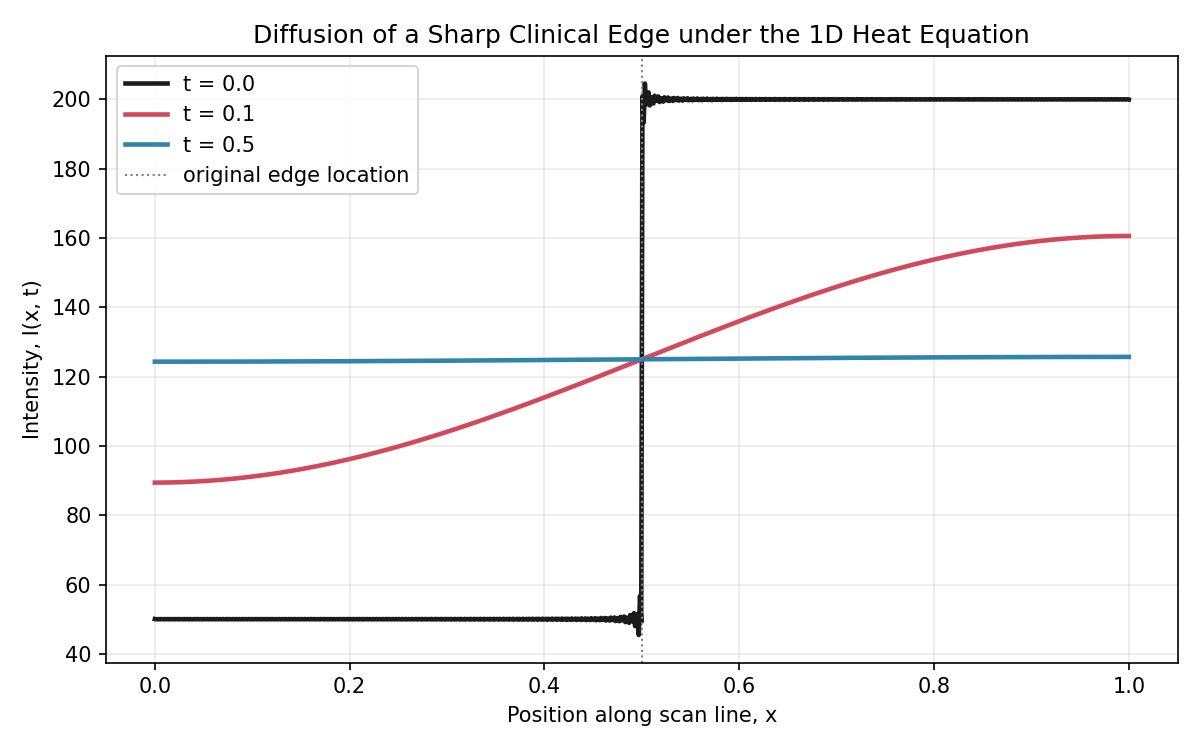

In [ ]:
x = np.linspace(0, L, 800)
time_steps = [0.0, 0.1, 0.5]
colors = ["#1b1b1b", "#d1495b", "#2e86ab"]

fig, ax = plt.subplots(figsize=(8, 5))
for t, c in zip(time_steps, colors):
    y = I_xt(x, t)
    ax.plot(x, y, color=c, linewidth=2.2, label=f"t = {t}")

ax.axvline(x0, color="gray", linestyle=":", linewidth=1, label="original edge location")
ax.set_xlabel("Position along scan line, x")
ax.set_ylabel("Intensity, I(x, t)")
ax.set_title("Diffusion of a Sharp Clinical Edge under the 1D Heat Equation")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("diffusion_edge_evolution.png", dpi=150)
plt.show()


## 5. Low-Pass Filtering in the Frequency Domain

To make the *mechanism* of blurring explicit (rather than just its visual effect),
we plot the retained amplitude of each odd harmonic, $|a_n|\,e^{-\alpha(n\pi/L)^2 t}$,
as a function of harmonic index $n$, at the same three times. This directly visualises
the transfer function $H_t(n)=e^{-\alpha(n\pi/L)^2 t}$ derived in Phase 1, Section 12:
it is essentially flat (no filtering) at $t=0$ and collapses into a narrow low-pass
window as $t$ increases, letting only the lowest harmonics survive.

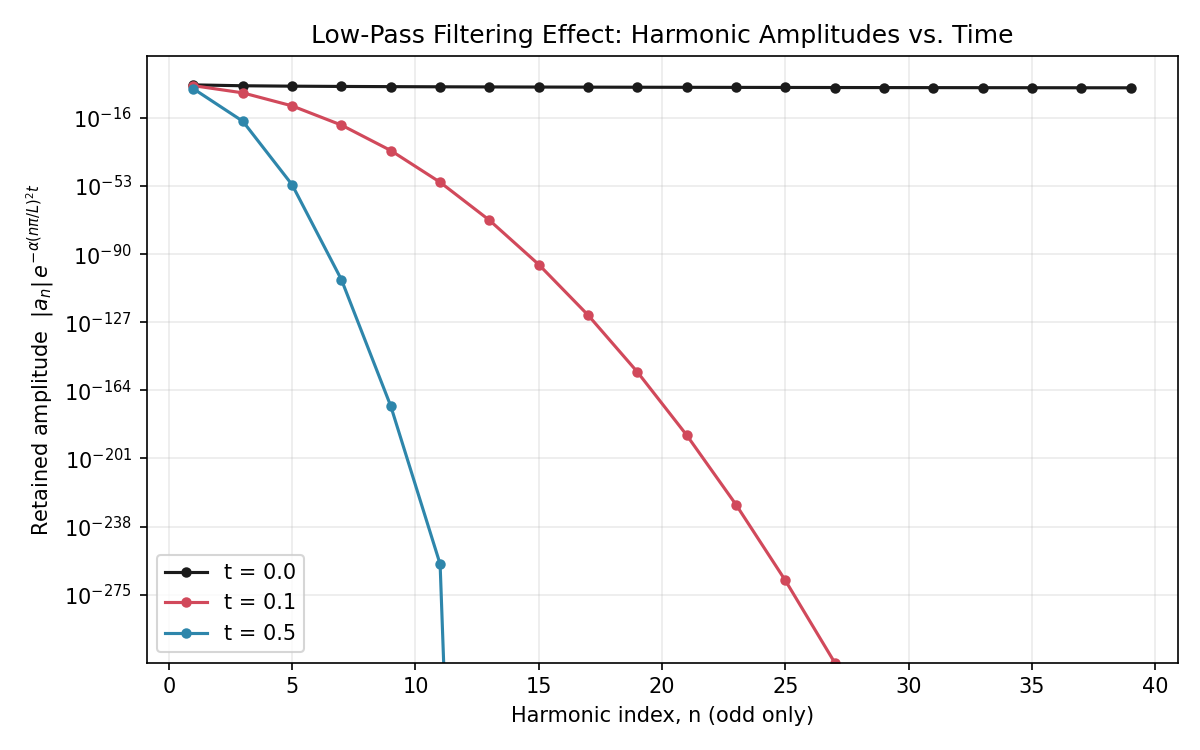

In [ ]:
n_values = np.arange(1, 41, 2)  # odd harmonics 1, 3, 5, ..., 39

fig, ax = plt.subplots(figsize=(8, 5))
for t, c in zip(time_steps, colors):
    amplitudes = [abs(fourier_coefficient(n)) * np.exp(-alpha * (n * np.pi / L) ** 2 * t)
                  for n in n_values]
    ax.plot(n_values, amplitudes, "o-", color=c, markersize=4, label=f"t = {t}")

ax.set_xlabel("Harmonic index, n (odd only)")
ax.set_ylabel(r"Retained amplitude  $|a_n|\,e^{-\alpha (n\pi/L)^2 t}$")
ax.set_title("Low-Pass Filtering Effect: Harmonic Amplitudes vs. Time")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.savefig("lowpass_spectrum.png", dpi=150)
plt.show()


## 6. Convergence Check: Effect of Truncation Order $N$

Because the initial data is discontinuous, its Fourier series converges slowly near
the edge (Gibbs phenomenon). The cell below confirms that our truncation
`N_TERMS = 500` is already visually converged at $t=0$ by comparing partial sums
with $N = 20, 100, 500$.

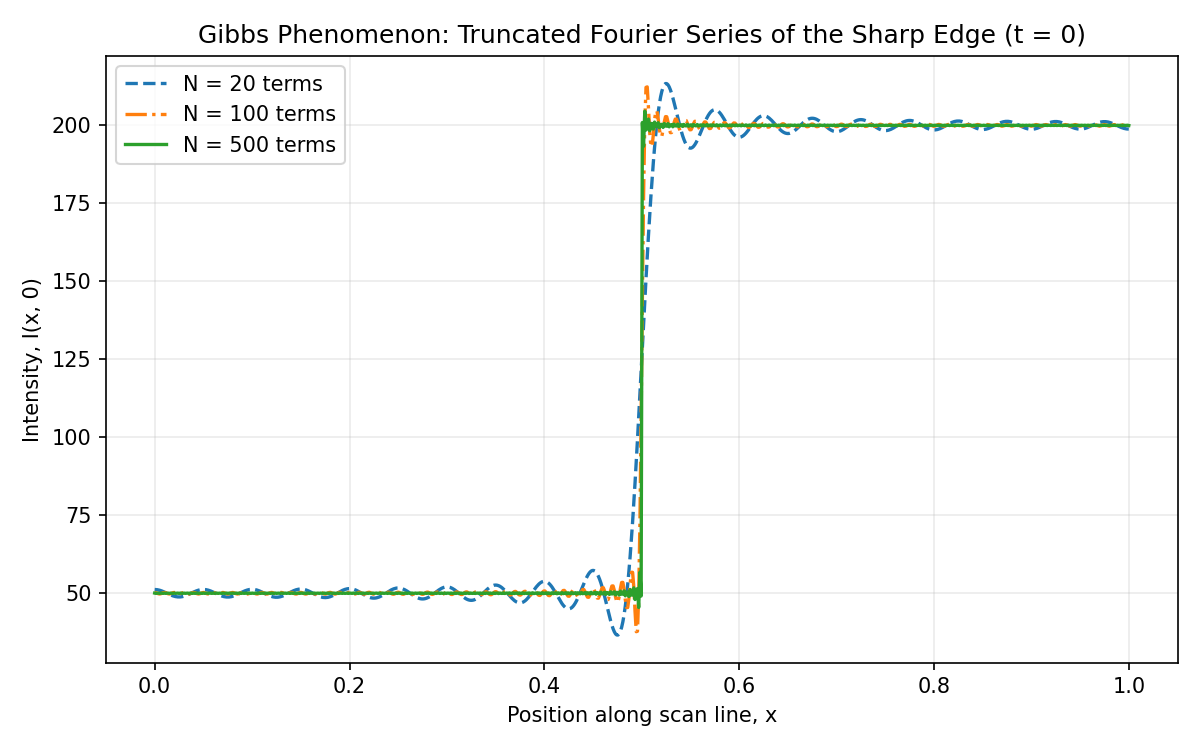

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for N, style in zip([20, 100, 500], ["--", "-.", "-"]):
    y = I_xt(x, 0.0, N=N)
    ax.plot(x, y, style, linewidth=1.6, label=f"N = {N} terms")

ax.set_xlabel("Position along scan line, x")
ax.set_ylabel("Intensity, I(x, 0)")
ax.set_title("Gibbs Phenomenon: Truncated Fourier Series of the Sharp Edge (t = 0)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("gibbs_convergence.png", dpi=150)
plt.show()


## 7. Discussion and Engineering Conclusions

**Physical interpretation of the results:**

- **Progressive edge smoothing (Section 4):** the three curves in the first plot
  reproduce exactly the qualitative prediction of Phase 1 — the step at $t=0$ widens
  into a smooth transition band whose width grows with $t$, while its centre value
  and the overall mean intensity $(I_0+I_1)/2 = 125$ stay fixed, confirming the
  intensity-conservation property of the Neumann boundary conditions used in the
  analytical derivation.

- **Low-pass filtering in the spectrum (Section 5):** the harmonic-amplitude plot
  shows directly that high-index harmonics are suppressed by many orders of magnitude
  well before low-index harmonics are noticeably affected — a numerical confirmation
  of the $\gamma_n \propto n^2$ decay-rate law proved analytically in Phase 1,
  Section 11 (Proposition 1). This is the precise mechanism, visualised, by which
  diffusion erases fine image detail (edges, small lesions, texture) far faster than
  it erases broad-scale contrast.

- **Gibbs phenomenon and numerical convergence (Section 6):** at $t=0$ the partial
  sums exhibit the classic Gibbs overshoot near the discontinuity, which does **not**
  disappear as $N$ increases (only narrows). This overshoot is a numerical artefact
  of truncating an infinite series representing a discontinuous function, not a
  physical feature of the image — for any $t>0$, exponential damping of the high
  harmonics removes the overshoot almost immediately, consistent with the theory.

**Engineering takeaway.** Since blurring acts as a frequency-selective (Gaussian-type)
low-pass filter, *restoration* (deblurring) of a diffused clinical image line requires
selectively re-amplifying the high-frequency components in proportion to the inverse
of the same transfer function, $H_t(n)^{-1} = e^{+\alpha (n\pi/L)^2 t}$ — the basis of
inverse-filtering / deconvolution approaches to medical image restoration. In practice
this inversion is ill-posed for large $n$ (noise is amplified faster than signal),
which is why regularised deconvolution (e.g. Wiener filtering) is used instead of a
naive inverse filter.
